# QC for final assemblies

1. Input QC
- ReadStats UL/HQ
- ReadStats PoreC

2. Assembly QC
- A: Full Table
- B: Selected Summary Table
- C: HPRC table
- D: Method comparison table

In [1]:
suppressPackageStartupMessages(library(tidyverse))
suppressPackageStartupMessages(library(ggplot2))
suppressPackageStartupMessages(library(gt))
suppressPackageStartupMessages(library(openxlsx))
source("../scripts/00_R_presets.R")

Warning message:
“package ‘ggplot2’ was built under R version 4.5.3”
Warning message:
“package ‘purrr’ was built under R version 4.5.3”
Warning message:
“package ‘dplyr’ was built under R version 4.5.3”
Scanning ttf files in ../../doc/figures/helvetica ...

Extracting .afm files from .ttf files...

/mnt/storage3b/projects/no_ngsd/ahthapp1_T2T_ONT/doc/figures/helvetica/Helvetica Condensed Regular.ttf
 : Helvetica-Condensed already registered in fonts database. Skipping.

/mnt/storage3b/projects/no_ngsd/ahthapp1_T2T_ONT/doc/figures/helvetica/Helvetica Roman.ttf
 : Helvetica already registered in fonts database. Skipping.

/mnt/storage3b/projects/no_ngsd/ahthapp1_T2T_ONT/doc/figures/helvetica/helvetica_condensed.ttf
 : Helvetica-Condensed already registered in fonts database. Skipping.

/mnt/storage3b/projects/no_ngsd/ahthapp1_T2T_ONT/doc/figures/helvetica/Helvetica-Bold Oblique.ttf
 : Helvetica-BoldOblique already registered in fonts database. Skipping.

/mnt/storage3b/projects/no_ngsd/a

In [2]:
# Define list of samples
samples <- c(
    "T2T_HG002",
    "T2T00",
    "T2T00_1",
    "T2T00_2",
    "T2T01",
    "T2T02",
    "T2T03",
    "T2T04",
    "T2T04_1",
    "T2T04_2",
    "T2T05",
    "T2T06",
    "T2T07",
    "T2T08",
    "T2T09",
    "T2T10",
    "T2T11",
    "T2T12",
    "T2T13",
    "T2T15",
    "T2T16",
    "T2T17",
    "T2T18",
    "T2T19",
    "T2T_HG002"
)

## 1. Input QC

In [3]:
# Load read stats
source("../scripts/02_plot_read_stats.R")

types <- c("HQ_herro.50x", "UL.70x", "POREC")

dt_input_qc <- expand.grid(sample = samples, type = types) %>%
    mutate(path = paste0("../../assembly/input_qc/", sample, "/", sample, ".", type, "/read_stats.txt"))

dt_input_qc

KernSmooth 2.23 loaded
Copyright M. P. Wand 1997-2009



sample,type,path
<fct>,<fct>,<chr>
T2T_HG002,HQ_herro.50x,../../assembly/input_qc/T2T_HG002/T2T_HG002.HQ_herro.50x/read_stats.txt
T2T00,HQ_herro.50x,../../assembly/input_qc/T2T00/T2T00.HQ_herro.50x/read_stats.txt
T2T00_1,HQ_herro.50x,../../assembly/input_qc/T2T00_1/T2T00_1.HQ_herro.50x/read_stats.txt
T2T00_2,HQ_herro.50x,../../assembly/input_qc/T2T00_2/T2T00_2.HQ_herro.50x/read_stats.txt
T2T01,HQ_herro.50x,../../assembly/input_qc/T2T01/T2T01.HQ_herro.50x/read_stats.txt
T2T02,HQ_herro.50x,../../assembly/input_qc/T2T02/T2T02.HQ_herro.50x/read_stats.txt
T2T03,HQ_herro.50x,../../assembly/input_qc/T2T03/T2T03.HQ_herro.50x/read_stats.txt
T2T04,HQ_herro.50x,../../assembly/input_qc/T2T04/T2T04.HQ_herro.50x/read_stats.txt
T2T04_1,HQ_herro.50x,../../assembly/input_qc/T2T04_1/T2T04_1.HQ_herro.50x/read_stats.txt


In [4]:
# Process read stats
dt_l <- list()
for (i in 1:nrow(dt_input_qc)) {
    print(paste("Processing", dt_input_qc$sample[i]))
    dt_l[[dt_input_qc$path[i]]] <- process_sequencing_file(dt_input_qc$path[i])
} 

[1] "Processing T2T_HG002"
[1] "Reading file: ../../assembly/input_qc/T2T_HG002/T2T_HG002.HQ_herro.50x/read_stats.txt"
[1] "Calculating summary statistics"
[1] "Calculating 1D density for read length"
[1] "Calculating 1D density for mean quality"
[1] "Calculating 2D density"


Warning message in calculate_2d_density(result$plot_data):
“Skipping 2D density for sample T2T_HG002_HQ_herro.50x due to insufficient variation”


[1] "Calculating read length histogram"
[1] "Processing T2T00"
[1] "Reading file: ../../assembly/input_qc/T2T00/T2T00.HQ_herro.50x/read_stats.txt"
[1] "Calculating summary statistics"
[1] "Calculating 1D density for read length"
[1] "Calculating 1D density for mean quality"
[1] "Calculating 2D density"


Warning message in calculate_2d_density(result$plot_data):
“Skipping 2D density for sample GE-MED-T2T00_HQ_herro.50x due to insufficient variation”


[1] "Calculating read length histogram"
[1] "Processing T2T00_1"
[1] "Reading file: ../../assembly/input_qc/T2T00_1/T2T00_1.HQ_herro.50x/read_stats.txt"
[1] "Calculating summary statistics"
[1] "Calculating 1D density for read length"
[1] "Calculating 1D density for mean quality"
[1] "Calculating 2D density"


...

[1] "Calculating read length histogram"
[1] "Processing T2T19"
[1] "Reading file: ../../assembly/input_qc/T2T19/T2T19.POREC/read_stats.txt"
[1] "Calculating summary statistics"
[1] "Calculating 1D density for read length"
[1] "Calculating 1D density for mean quality"
[1] "Calculating 2D density"


Warning message in bkfe(gcounts, 4L, alpha, range.x = c(sa, sb), binned = TRUE):
“Binning grid too coarse for current (small) bandwidth: consider increasing 'gridsize'”
Warning message in bkde2D(cbind(x_vals, y_vals), bandwidth = c(h1, h2), gridsize = c(n, :
“Binning grid too coarse for current (small) bandwidth: consider increasing 'gridsize'”


[1] "Calculating read length histogram"
[1] "Processing T2T_HG002"
[1] "Reading file: ../../assembly/input_qc/T2T_HG002/T2T_HG002.POREC/read_stats.txt"
[1] "Calculating summary statistics"
[1] "Calculating 1D density for read length"
[1] "Calculating 1D density for mean quality"
[1] "Calculating 2D density"


Warning message in bkfe(gcounts, 4L, alpha, range.x = c(sa, sb), binned = TRUE):
“Binning grid too coarse for current (small) bandwidth: consider increasing 'gridsize'”
Warning message in bkde2D(cbind(x_vals, y_vals), bandwidth = c(h1, h2), gridsize = c(n, :
“Binning grid too coarse for current (small) bandwidth: consider increasing 'gridsize'”


[1] "Calculating read length histogram"


In [5]:
# Crate summary tables
for (i in 1:length(dt_l)) {
    dt_l[[i]]$summary_stats$path <- names(dt_l)[i]
    dt_l[[i]]$read_length_density$path <- names(dt_l)[i]
    dt_l[[i]]$quality_density$path <- names(dt_l)[i]
    dt_l[[i]]$density_2d$path <- names(dt_l)[i]
}
dt_stats <- bind_rows(lapply(dt_l, function(x) x$summary_stats)) %>%
    inner_join(dt_input_qc, by = c("path" = "path")) %>%
    select(c(-sample_name))
dt_read_length_density <- bind_rows(lapply(dt_l, function(x) x$read_length_density)) %>%
        inner_join(dt_input_qc, by = c("path" = "path"))%>%
    select(c(-sample_name))
dt_quality_density <- bind_rows(lapply(dt_l, function(x) x$quality_density))%>%
        inner_join(dt_input_qc, by = c("path" = "path"))%>%
    select(c(-sample_name))
dt_density_2d <- bind_rows(lapply(dt_l, function(x) x$density_2d))%>%
        inner_join(dt_input_qc, by = c("path" = "path"))%>%
    select(c(-sample_name))


Warning message in inner_join(., dt_input_qc, by = c(path = "path")):
“Detected an unexpected many-to-many relationship between `x` and `y`.
ℹ Row 1 of `x` matches multiple rows in `y`.
ℹ Row 1 of `y` matches multiple rows in `x`.
ℹ If a many-to-many relationship is expected, set `relationship =
  "many-to-many"` to silence this warning.”
Warning message in inner_join(., dt_input_qc, by = c(path = "path")):
“Detected an unexpected many-to-many relationship between `x` and `y`.
ℹ Row 1 of `x` matches multiple rows in `y`.
ℹ Row 1 of `y` matches multiple rows in `x`.
ℹ If a many-to-many relationship is expected, set `relationship =
  "many-to-many"` to silence this warning.”
Warning message in inner_join(., dt_input_qc, by = c(path = "path")):
“Detected an unexpected many-to-many relationship between `x` and `y`.
ℹ Row 1 of `x` matches multiple rows in `y`.
ℹ Row 26 of `y` matches multiple rows in `x`.
ℹ If a many-to-many relationship is expected, set `relationship =
  "many-to-many"` to

In [6]:
# Create reduced table
dt_stats_reduced <- dt_stats %>%
    select(sample, type, total_bases, N50, yield_above_100kb, median_quality, reads_above_1MB)
head(dt_stats_reduced)

# Save table to file
write_tsv(dt_stats_reduced, file = "../../doc/tables/for_plots/assembly_input_read_stats.tsv")


sample,type,total_bases,N50,yield_above_100kb,median_quality,reads_above_1MB
<fct>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
T2T_HG002,HQ_herro.50x,160000012469,74758,52814479591,33,0
T2T_HG002,HQ_herro.50x,160000012469,74758,52814479591,33,0
T2T00,HQ_herro.50x,160000022814,80466,56517647266,33,0
T2T00_1,HQ_herro.50x,160000026078,85478,59838794006,33,0
T2T00_2,HQ_herro.50x,160000013431,55034,39255767318,33,3
T2T01,HQ_herro.50x,156876555610,79387,59520591251,33,4


Rows: 75 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (2): sample, type
dbl (5): total_bases, N50, yield_above_100kb, median_quality, reads_above_1MB

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


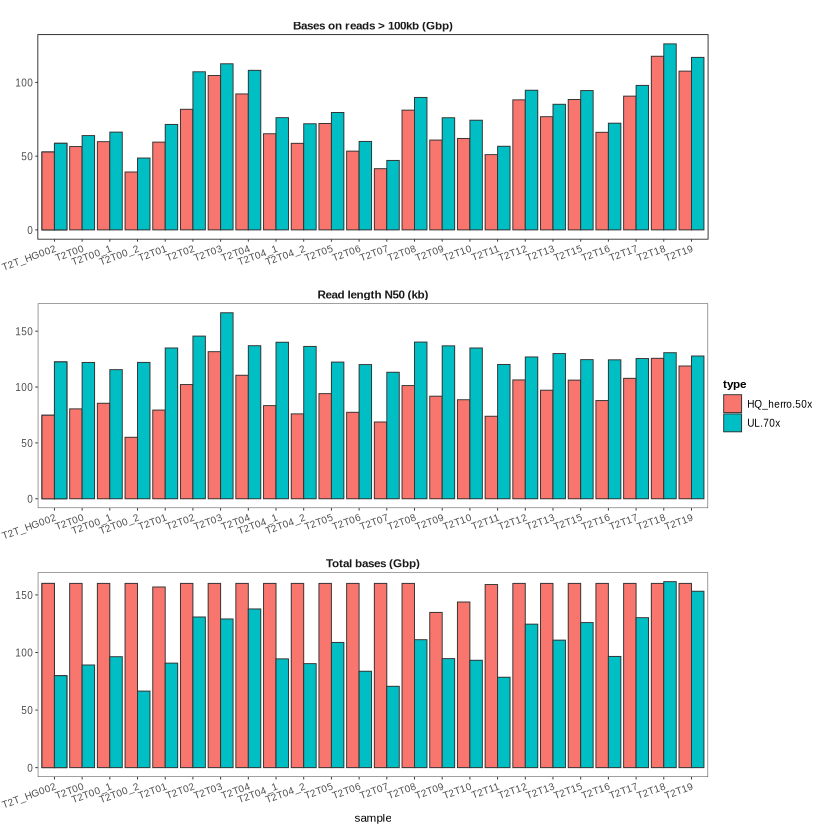

In [7]:
dt_stats_reduced <- read_tsv("../../doc/tables/for_plots/assembly_input_read_stats.tsv")

# Plot read stat histograms
dt_stats_long <- dt_stats_reduced %>%
  pivot_longer(
    cols = -c(sample, type),
    names_to = "metric",
    values_to = "value"
  ) %>%
  filter(!metric %in% c("reads_above_1MB", "median_quality")) %>%
  mutate(
    # Convert values to appropriate units
    value = case_when(
      metric == "total_bases" ~ value / 1e9,  # Convert to Gbp
      metric == "yield_above_100kb" ~ value / 1e9,  # Convert to Gbp
      metric == "N50" ~ value / 1000,  # Convert to kb
      TRUE ~ value
    ),
    # Update metric labels
    metric = case_when(
      metric == "total_bases" ~ "Total bases (Gbp)",
      metric == "yield_above_100kb" ~ "Bases on reads > 100kb (Gbp)", 
      metric == "N50" ~ "Read length N50 (kb)",
      TRUE ~ metric
    )
  )

p_input_qc <- ggplot(dt_stats_long %>% filter(type != "POREC"), aes(x = sample, y = value, fill = type)) +
    geom_bar(stat = "identity", position = "dodge", col = "grey20") +
    facet_wrap(~metric, scales = "free", ncol = 1) + 
    theme(axis.text.x = element_text(angle = 20, hjust = 1)) +
    labs(y = NULL)  # Remove y-axis label since units are now in facet titles

p_input_qc
ggsave("../../doc/figures/input_qc_read_stats.png", p_input_qc, width = 7, height = 5)
ggsave("../../doc/figures/input_qc_read_stats.pdf", p_input_qc, width = 7, height = 5)

In [8]:
# Calculate Yield and N50 summary stats (Median, Mean, SD) for both HQ_herro.50x and UL.70x
dt_stats_summary <- dt_stats_reduced %>%
    filter(type %in% c("HQ_herro.50x", "UL.70x", "POREC")) %>%
    group_by(type) %>%
    summarise(
        yield_median_Gbp = median(total_bases) / 1e9,
        yield_mean_Gbp = mean(total_bases) / 1e9,
        yield_sd_Gbp = sd(total_bases) / 1e9,
        N50_median_kb = median(N50) / 1000,
        N50_mean_kb = mean(N50) / 1000,
        N50_sd_kb = sd(N50) / 1000
    )

dt_stats_summary


type,yield_median_Gbp,yield_mean_Gbp,yield_sd_Gbp,N50_median_kb,N50_mean_kb,N50_sd_kb
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
HQ_herro.50x,160.00002,158.1805,5.861716,88.642,91.98040,18.70021
POREC,120.15199,112.6600,26.751159,8.078,7.82096,1.57975
UL.70x,96.34862,105.1367,25.530484,126.921,129.71672,11.26248


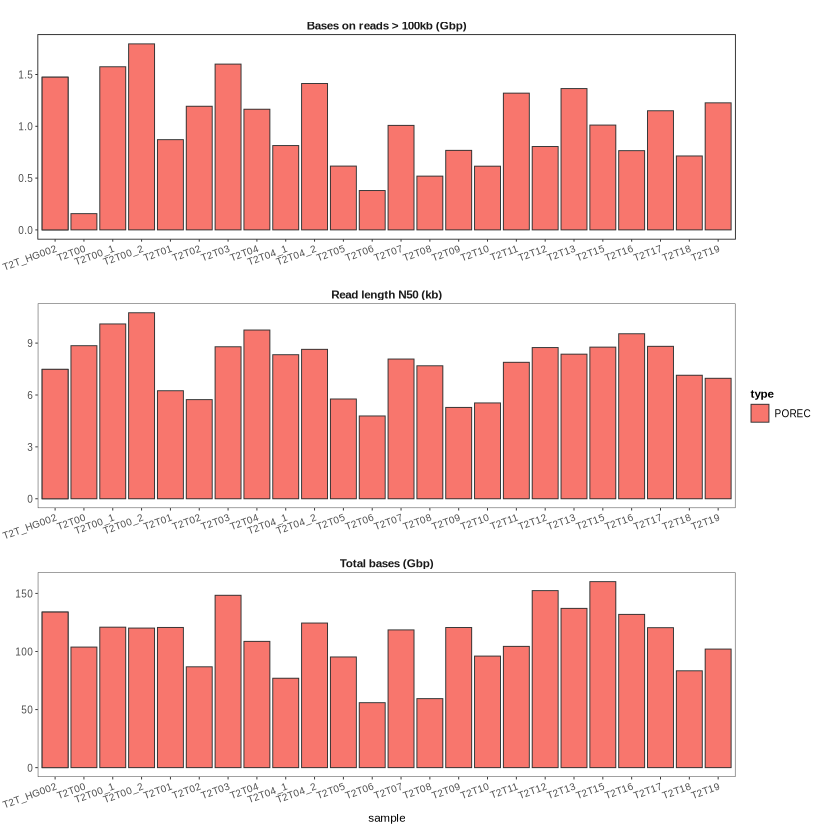

In [9]:
p_input_qc_porec <- ggplot(dt_stats_long %>% filter(type == "POREC"), aes(x = sample, y = value, fill = type)) +
    geom_bar(stat = "identity", position = "dodge", col = "grey20") +
    facet_wrap(~metric, scales = "free", ncol = 1) + 
    theme(axis.text.x = element_text(angle = 20, hjust = 1)) +
    labs(y = NULL)  # Remove y-axis label since units are now in facet titles

p_input_qc_porec
ggsave("../../doc/figures/input_qc_read_stats_porec.png", p_input_qc_porec, width = 7, height = 5)
ggsave("../../doc/figures/input_qc_read_stats_porec.pdf", p_input_qc_porec, width = 7, height = 5)

## 2.) Assembly QC Results

In [10]:
source("../scripts/00_R_presets.R")

Scanning ttf files in ../../doc/figures/helvetica ...

Extracting .afm files from .ttf files...

/mnt/storage3b/projects/no_ngsd/ahthapp1_T2T_ONT/doc/figures/helvetica/Helvetica Condensed Regular.ttf
 : Helvetica-Condensed already registered in fonts database. Skipping.

/mnt/storage3b/projects/no_ngsd/ahthapp1_T2T_ONT/doc/figures/helvetica/Helvetica Roman.ttf
 : Helvetica already registered in fonts database. Skipping.

/mnt/storage3b/projects/no_ngsd/ahthapp1_T2T_ONT/doc/figures/helvetica/helvetica_condensed.ttf
 : Helvetica-Condensed already registered in fonts database. Skipping.

/mnt/storage3b/projects/no_ngsd/ahthapp1_T2T_ONT/doc/figures/helvetica/Helvetica-Bold Oblique.ttf
 : Helvetica-BoldOblique already registered in fonts database. Skipping.

/mnt/storage3b/projects/no_ngsd/ahthapp1_T2T_ONT/doc/figures/helvetica/Helvetica-Bold.ttf
 : Helvetica-Bold already registered in fonts database. Skipping.

/mnt/storage3b/projects/no_ngsd/ahthapp1_T2T_ONT/doc/figures/helvetica/helvetic

In [11]:
# Show All QC metrics:
read_tsv("../../assembly/qc/qc_samples.tsv", show_col_types = FALSE) %>%
    select(metric, source) %>% 
    unique() %>%
    print(n = Inf)


# A tibble: 106 × 2
    metric                              source           
    <chr>                               <chr>            
  1 mapped_sequences_n                  stat             
  2 primary_alignments_n                stat             
  3 secondary_alignments_n              stat             
  4 primary_alignments_long_cigar_n     stat             
  5 bases_in_mapped_sequences           stat             
  6 bases_mapped                        stat             
  7 substitutions                       stat             
  8 insertions_length_0_50              stat             
  9 insertions_length_50_100            stat             
 10 insertions_length_100_300           stat             
 11 insertions_length_300_400           stat             
 12 insertions_length_400_1000          stat             
 13 insertions_length_1000_inf          stat             
 14 deletions_length_0_50               stat             
 15 deletions_length_50_100             stat        

In [12]:
# Read qc_samples.tsv (Full table)

source("../scripts/13_process_assembly_qc.R")

dt_samples <- read_tsv("../../assembly/qc/qc_samples.tsv", show_col_types = FALSE) %>%
    process_qc_table(selection = metrics_full) %>%
    mutate(haplotype = ifelse(is.na(haplotype), "both", haplotype))

head(dt_samples)
print(unique(dt_samples$metric))

write_tsv(dt_samples, "../../doc/tables/qc_samples_table_full.tsv")

metric,value,haplotype,asm_method,asm_name,source,chromosome
<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>
length,2.926889e+09,haplotype1,phased_verkko,T2T00,asmstat,NA
ref_covered,9.031000e-01,haplotype1,phased_verkko,T2T00,asmstat,NA
asm_covered,9.698000e-01,haplotype1,phased_verkko,T2T00,asmstat,NA
length,3.038359e+09,haplotype2,phased_verkko,T2T00,asmstat,NA
ref_covered,9.339000e-01,haplotype2,phased_verkko,T2T00,asmstat,NA
asm_covered,9.682000e-01,haplotype2,phased_verkko,T2T00,asmstat,NA


 [1] "length"                              "ref_covered"                        
 [3] "asm_covered"                         "inter-chromosomal_misjoins"         
 [5] "intra-chromosomal_gaps"              "candidate_inversions_in_the_middle" 
 [7] "candidate_inversions_at_contig_ends" "total_n_count"                      
 [9] "total_gaps"                          "n_contigs"                          
[11] "n_contigs_over_10mb"                 "n_t2t_contig"                       
[13] "n_t2t_scaffold"                      "genome_completeness"                
[15] "MMC"                                 "MSC"                                
[17] "total_blocks"                        "total_covered_variants"             
[19] "total_switches"                      "total_het_variants"                 
[21] "overall_switch_rate"                 "overall_switchflip_rate"            
[23] "overall_hamming_rate"               


### A) Full table

In [13]:
# Transform table to wide format and print markdown
dt_wide <- qc_table_to_wide(dt_samples, col_order = metrics_full ) %>%
  write_tsv("../../doc/tables/qc_samples_full_wide.tsv")
print(knitr::kable(dt_wide), format = "markdown")



|asm_name  |haplotype  |     length| n_contigs_over_10mb| n_contigs| n_t2t_contig| n_t2t_scaffold| ref_covered| asm_covered| genome_completeness|       MMC|       MSC| inter-chromosomal_misjoins| intra-chromosomal_gaps| candidate_inversions_in_the_middle| candidate_inversions_at_contig_ends| total_gaps| total_n_count| total_covered_variants| overall_switch_rate| total_blocks| total_switches| total_het_variants| overall_switchflip_rate| overall_hamming_rate|
|:---------|:----------|----------:|-------------------:|---------:|------------:|--------------:|-----------:|-----------:|-------------------:|---------:|---------:|--------------------------:|----------------------:|----------------------------------:|-----------------------------------:|----------:|-------------:|----------------------:|-------------------:|------------:|--------------:|------------------:|-----------------------:|--------------------:|
|T2T00     |haplotype1 | 2926888795|                  23|        44|      

In [14]:
# Print pretty full QC table
sample_qc_gt_full <- qc_table_pretty(dt_wide) 
sample_qc_gt_full %>% as_raw_html() %>% IRdisplay::display_html()



Warning message:
“Since gt v0.6.0 `fmt_missing()` is deprecated and will soon be removed.
ℹ Use `sub_missing()` instead.
This warning is displayed once every 8 hours.”


<table class="gt_table" data-quarto-disable-processing="false" data-quarto-bootstrap="false" style="-webkit-font-smoothing: antialiased; -moz-osx-font-smoothing: grayscale; font-family: system-ui, 'Segoe UI', Roboto, Helvetica, Arial, sans-serif, 'Apple Color Emoji', 'Segoe UI Emoji', 'Segoe UI Symbol', 'Noto Color Emoji'; display: table; border-collapse: collapse; line-height: normal; margin-left: auto; margin-right: auto; color: #333333; font-size: 16px; font-weight: normal; font-style: normal; background-color: #FFFFFF; width: 90%; border-top-style: solid; border-top-width: 2px; border-top-color: #000000; border-right-style: none; border-right-width: 2px; border-right-color: #D3D3D3; border-bottom-style: solid; border-bottom-width: 2px; border-bottom-color: #000000; border-left-style: none; border-left-width: 2px; border-left-color: #D3D3D3;" width="90%" bgcolor="#FFFFFF">
 
 
 Assembly QC Metrics 
 
 
 <td colspan="25" class="gt_heading gt_subtitle gt_font_normal gt_bottom_border" style="border-style: none; color: #333333; font-size: 15px; padding-top: 3px; padding-bottom: 5px; padding-left: 5px; padding-right: 5px; border-top-color: #FFFFFF; border-top-width: 0; background-color: #FFFFFF; text-align: center; border-left-style: none; border-left-width: 1px; border-left-color: #D3D3D3; border-right-style: none; border-right-width: 1px; border-right-color: #D3D3D3; border-bottom-style: solid; border-bottom-width: 2px; border-bottom-color: #D3D3D3; font-weight: normal;" bgcolor="#FFFFFF" align="center">Selected metrics 
 
 
 <th class="gt_col_heading gt_columns_bottom_border gt_left" rowspan="1" colspan="1" scope="col" id="a::stub" style="border-style: none; color: #333333; background-color: #FFFFFF; font-size: 100%; font-weight: bold; text-transform: inherit; border-left-style: none; border-left-width: 1px; border-left-color: #D3D3D3; border-right-style: none; border-right-width: 1px; border-right-color: #D3D3D3; vertical-align: bottom; padding-top: 5px; padding-bottom: 6px; padding-left: 5px; padding-right: 5px; overflow-x: hidden; text-align: left;" bgcolor="#FFFFFF" valign="bottom" align="left"> 
 <th class="gt_col_heading gt_columns_bottom_border gt_left" rowspan="1" colspan="1" scope="col" id="asm_name" style="border-style: none; color: #333333; background-color: #FFFFFF; font-size: 100%; font-weight: bold; text-transform: inherit; border-left-style: none; border-left-width: 1px; border-left-color: #D3D3D3; border-right-style: none; border-right-width: 1px; border-right-color: #D3D3D3; vertical-align: bottom; padding-top: 5px; padding-bottom: 6px; padding-left: 5px; padding-right: 5px; overflow-x: hidden; text-align: left;" bgcolor="#FFFFFF" valign="bottom" align="left">Assembly 
 <th class="gt_col_heading gt_columns_bottom_border gt_center" rowspan="1" colspan="1" scope="col" id="length" style="border-style: none; color: #333333; background-color: #FFFFFF; font-size: 100%; font-weight: bold; text-transform: inherit; border-left-style: none; border-left-width: 1px; border-left-color: #D3D3D3; border-right-style: none; border-right-width: 1px; border-right-color: #D3D3D3; vertical-align: bottom; padding-top: 5px; padding-bottom: 6px; padding-left: 5px; padding-right: 5px; overflow-x: hidden; text-align: center;" bgcolor="#FFFFFF" valign="bottom" align="center">Assembly Length 
 <th class="gt_col_heading gt_columns_bottom_border gt_center" rowspan="1" colspan="1" scope="col" id="n_contigs_over_10mb" style="border-style: none; color: #333333; background-color: #FFFFFF; font-size: 100%; font-weight: bold; text-transform: inherit; border-left-style: none; border-left-width: 1px; border-left-color: #D3D3D3; border-right-style: none; border-right-width: 1px; border-right-color: #D3D3D3; vertical-align: bottom; padding-top: 5px; padding-bottom: 6px; padding-left: 5px; padding-right: 5px; overflow-x: hidden; text-align: center;" bgcolor="#FFFFFF" valign="bottom" align="center">Contigs >10Mbp 
 <th class="gt_col_heading gt_column

In [15]:
# save full table
gt::gtsave(sample_qc_gt_full, "../../doc/tables/qc_samples_full_table.html")
gt::gtsave(sample_qc_gt_full, "../../doc/tables/qc_samples_full_table.docx")  # Word/Excel compatible
sample_qc_gt_full %>%
  as_latex() %>%
  writeLines("../../doc/tables/qc_samples_full_table.tex")  # LaTeX format

ERROR: Error: pandoc is required and was not found (see the help page ?rmarkdown::pandoc_available).


In [ ]:
export_excel(dt_wide, "../../doc/tables/qc_samples_full_table.xlsx")

## B) Selected summary table

In [ ]:
# Select and prepare data
dt_summary <- dt_wide %>%
select(
    asm_name,
    haplotype,
    all_of(metrics_summary)
) %>%
filter(haplotype != "both") %>%
mutate(
    # Factor haplotype for desired order in table rows
    haplotype = factor(haplotype, levels = c("haplotype1", "haplotype2", "both"))
) %>%
arrange(asm_name, haplotype)

print(dt_summary)


# A tibble: 48 × 11
   asm_name haplotype     length n_t2t_contig n_t2t_scaffold n_contigs_over_10mb
   <chr>    <fct>          <dbl>        <dbl>          <dbl>               <dbl>
 1 T2T00    haplotype1    2.93e9            9             11                  23
 2 T2T00    haplotype2    3.04e9            8             12                  23
 3 T2T00_1  haplotype1    2.88e9            8             10                  22
 4 T2T00_1  haplotype2    3.09e9            6             12                  24
 5 T2T00_2  haplotype1    3.04e9            0              9                  32
 6 T2T00_2  haplotype2    3.08e9            1              9                  30
 7 T2T01    haplotype1    3.01e9           10              8                  23
 8 T2T01    haplotype2    3.02e9            8             10                  23
 9 T2T02    haplotype1    2.93e9            7             10                  25
10 T2T02    haplotype2    3.04e9            7             11                  24
# ℹ 38 m

In [ ]:
# Print pretty QC table
sample_qc_gt_summary <- qc_table_pretty(dt_summary) 
sample_qc_gt_summary %>% as_raw_html() %>% IRdisplay::display_html()

<table class="gt_table" data-quarto-disable-processing="false" data-quarto-bootstrap="false" style="-webkit-font-smoothing: antialiased; -moz-osx-font-smoothing: grayscale; font-family: system-ui, 'Segoe UI', Roboto, Helvetica, Arial, sans-serif, 'Apple Color Emoji', 'Segoe UI Emoji', 'Segoe UI Symbol', 'Noto Color Emoji'; display: table; border-collapse: collapse; line-height: normal; margin-left: auto; margin-right: auto; color: #333333; font-size: 16px; font-weight: normal; font-style: normal; background-color: #FFFFFF; width: 90%; border-top-style: solid; border-top-width: 2px; border-top-color: #000000; border-right-style: none; border-right-width: 2px; border-right-color: #D3D3D3; border-bottom-style: solid; border-bottom-width: 2px; border-bottom-color: #000000; border-left-style: none; border-left-width: 2px; border-left-color: #D3D3D3;" width="90%" bgcolor="#FFFFFF">
 
 
 Assembly QC Metrics 
 
 
 <td colspan="11" class="gt_heading gt_subtitle gt_font_normal gt_bottom_border" style="border-style: none; color: #333333; font-size: 15px; padding-top: 3px; padding-bottom: 5px; padding-left: 5px; padding-right: 5px; border-top-color: #FFFFFF; border-top-width: 0; background-color: #FFFFFF; text-align: center; border-left-style: none; border-left-width: 1px; border-left-color: #D3D3D3; border-right-style: none; border-right-width: 1px; border-right-color: #D3D3D3; border-bottom-style: solid; border-bottom-width: 2px; border-bottom-color: #D3D3D3; font-weight: normal;" bgcolor="#FFFFFF" align="center">Selected metrics 
 
 
 <th class="gt_col_heading gt_columns_bottom_border gt_left" rowspan="1" colspan="1" scope="col" id="a::stub" style="border-style: none; color: #333333; background-color: #FFFFFF; font-size: 100%; font-weight: bold; text-transform: inherit; border-left-style: none; border-left-width: 1px; border-left-color: #D3D3D3; border-right-style: none; border-right-width: 1px; border-right-color: #D3D3D3; vertical-align: bottom; padding-top: 5px; padding-bottom: 6px; padding-left: 5px; padding-right: 5px; overflow-x: hidden; text-align: left;" bgcolor="#FFFFFF" valign="bottom" align="left"> 
 <th class="gt_col_heading gt_columns_bottom_border gt_left" rowspan="1" colspan="1" scope="col" id="asm_name" style="border-style: none; color: #333333; background-color: #FFFFFF; font-size: 100%; font-weight: bold; text-transform: inherit; border-left-style: none; border-left-width: 1px; border-left-color: #D3D3D3; border-right-style: none; border-right-width: 1px; border-right-color: #D3D3D3; vertical-align: bottom; padding-top: 5px; padding-bottom: 6px; padding-left: 5px; padding-right: 5px; overflow-x: hidden; text-align: left;" bgcolor="#FFFFFF" valign="bottom" align="left">Assembly 
 <th class="gt_col_heading gt_columns_bottom_border gt_center" rowspan="1" colspan="1" scope="col" id="length" style="border-style: none; color: #333333; background-color: #FFFFFF; font-size: 100%; font-weight: bold; text-transform: inherit; border-left-style: none; border-left-width: 1px; border-left-color: #D3D3D3; border-right-style: none; border-right-width: 1px; border-right-color: #D3D3D3; vertical-align: bottom; padding-top: 5px; padding-bottom: 6px; padding-left: 5px; padding-right: 5px; overflow-x: hidden; text-align: center;" bgcolor="#FFFFFF" valign="bottom" align="center">Assembly Length 
 <th class="gt_col_heading gt_columns_bottom_border gt_center" rowspan="1" colspan="1" scope="col" id="n_t2t_contig" style="border-style: none; color: #333333; background-color: #FFFFFF; font-size: 100%; font-weight: bold; text-transform: inherit; border-left-style: none; border-left-width: 1px; border-left-color: #D3D3D3; border-right-style: none; border-right-width: 1px; border-right-color: #D3D3D3; vertical-align: bottom; padding-top: 5px; padding-bottom: 6px; padding-left: 5px; padding-right: 5px; overflow-x: hidden; text-align: center;" bgcolor="#FFFFFF" valign="bottom" align="center">T2T Contigs 
 <th class="gt_col_heading gt_columns_bottom_b

In [ ]:
# save table
gt::gtsave(sample_qc_gt_summary, "../../doc/tables/qc_samples_summary_table.html")
gt::gtsave(sample_qc_gt_summary, "../../doc/tables/qc_samples_summary_table.docx")  # Word/Excel compatible
sample_qc_gt_summary %>%
  as_latex() %>%
  writeLines("../../doc/tables/qc_samples_summary_table.tex")  # LaTeX format

In [ ]:
export_excel(dt_summary, "../../doc/tables/qc_samples_summary_formatted.xlsx")

## 3) HPRC QC comparison

In [ ]:
source("../scripts/13_process_assembly_qc.R")
dt_hprc <- read_tsv("../../assembly/qc/qc_hprc.tsv", show_col_types = FALSE) %>%
    process_qc_table(selection = metrics_full) %>%
    mutate(haplotype = ifelse(is.na(haplotype), "both", haplotype))

head(dt_hprc)
print(unique(dt_hprc$metric))

write_tsv(dt_hprc, "../../doc/tables/qc_hprc_full.tsv")

metric,value,haplotype,asm_method,asm_name,source,chromosome
<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>
length,2.947895e+09,haplotype1,phased_hprc,HG002,asmstat,NA
ref_covered,9.075000e-01,haplotype1,phased_hprc,HG002,asmstat,NA
asm_covered,9.653000e-01,haplotype1,phased_hprc,HG002,asmstat,NA
length,3.051530e+09,haplotype2,phased_hprc,HG002,asmstat,NA
ref_covered,9.415000e-01,haplotype2,phased_hprc,HG002,asmstat,NA
asm_covered,9.686000e-01,haplotype2,phased_hprc,HG002,asmstat,NA


 [1] "length"                              "ref_covered"                        
 [3] "asm_covered"                         "inter-chromosomal_misjoins"         
 [5] "intra-chromosomal_gaps"              "candidate_inversions_in_the_middle" 
 [7] "candidate_inversions_at_contig_ends" "total_n_count"                      
 [9] "total_gaps"                          "n_contigs"                          
[11] "n_contigs_over_10mb"                 "n_t2t_contig"                       
[13] "n_t2t_scaffold"                      "genome_completeness"                
[15] "MMC"                                 "MSC"                                
[17] "total_blocks"                        "total_covered_variants"             
[19] "total_switches"                      "total_het_variants"                 
[21] "overall_switch_rate"                 "overall_switchflip_rate"            
[23] "overall_hamming_rate"               


In [ ]:
# HPRC: Transform table to wide format and print markdown
dt_hprc_full_wide <- qc_table_to_wide(dt_hprc, col_order = metrics_full ) %>%
  write_tsv("../../doc/tables/qc_hprc_full_wide.tsv")
print(knitr::kable(dt_hprc_full_wide), format = "markdown")



|asm_name |haplotype  |     length| n_contigs_over_10mb| n_contigs| n_t2t_contig| n_t2t_scaffold| ref_covered| asm_covered| genome_completeness|       MMC|       MSC| inter-chromosomal_misjoins| intra-chromosomal_gaps| candidate_inversions_in_the_middle| candidate_inversions_at_contig_ends| total_gaps| total_n_count| total_covered_variants| overall_switch_rate| total_blocks| total_switches| total_het_variants| overall_switchflip_rate| overall_hamming_rate|
|:--------|:----------|----------:|-------------------:|---------:|------------:|--------------:|-----------:|-----------:|-------------------:|---------:|---------:|--------------------------:|----------------------:|----------------------------------:|-----------------------------------:|----------:|-------------:|----------------------:|-------------------:|------------:|--------------:|------------------:|-----------------------:|--------------------:|
|HG002    |haplotype1 | 2947895164|                  23|        23|         

In [ ]:
# Print pretty full QC table
hprc_qc_gt_full <- qc_table_pretty(dt_hprc_full_wide) 
hprc_qc_gt_full %>% as_raw_html() %>% IRdisplay::display_html()

<table class="gt_table" data-quarto-disable-processing="false" data-quarto-bootstrap="false" style="-webkit-font-smoothing: antialiased; -moz-osx-font-smoothing: grayscale; font-family: system-ui, 'Segoe UI', Roboto, Helvetica, Arial, sans-serif, 'Apple Color Emoji', 'Segoe UI Emoji', 'Segoe UI Symbol', 'Noto Color Emoji'; display: table; border-collapse: collapse; line-height: normal; margin-left: auto; margin-right: auto; color: #333333; font-size: 16px; font-weight: normal; font-style: normal; background-color: #FFFFFF; width: 90%; border-top-style: solid; border-top-width: 2px; border-top-color: #000000; border-right-style: none; border-right-width: 2px; border-right-color: #D3D3D3; border-bottom-style: solid; border-bottom-width: 2px; border-bottom-color: #000000; border-left-style: none; border-left-width: 2px; border-left-color: #D3D3D3;" width="90%" bgcolor="#FFFFFF">
 
 
 Assembly QC Metrics 
 
 
 <td colspan="25" class="gt_heading gt_subtitle gt_font_normal gt_bottom_border" style="border-style: none; color: #333333; font-size: 15px; padding-top: 3px; padding-bottom: 5px; padding-left: 5px; padding-right: 5px; border-top-color: #FFFFFF; border-top-width: 0; background-color: #FFFFFF; text-align: center; border-left-style: none; border-left-width: 1px; border-left-color: #D3D3D3; border-right-style: none; border-right-width: 1px; border-right-color: #D3D3D3; border-bottom-style: solid; border-bottom-width: 2px; border-bottom-color: #D3D3D3; font-weight: normal;" bgcolor="#FFFFFF" align="center">Selected metrics 
 
 
 <th class="gt_col_heading gt_columns_bottom_border gt_left" rowspan="1" colspan="1" scope="col" id="a::stub" style="border-style: none; color: #333333; background-color: #FFFFFF; font-size: 100%; font-weight: bold; text-transform: inherit; border-left-style: none; border-left-width: 1px; border-left-color: #D3D3D3; border-right-style: none; border-right-width: 1px; border-right-color: #D3D3D3; vertical-align: bottom; padding-top: 5px; padding-bottom: 6px; padding-left: 5px; padding-right: 5px; overflow-x: hidden; text-align: left;" bgcolor="#FFFFFF" valign="bottom" align="left"> 
 <th class="gt_col_heading gt_columns_bottom_border gt_left" rowspan="1" colspan="1" scope="col" id="asm_name" style="border-style: none; color: #333333; background-color: #FFFFFF; font-size: 100%; font-weight: bold; text-transform: inherit; border-left-style: none; border-left-width: 1px; border-left-color: #D3D3D3; border-right-style: none; border-right-width: 1px; border-right-color: #D3D3D3; vertical-align: bottom; padding-top: 5px; padding-bottom: 6px; padding-left: 5px; padding-right: 5px; overflow-x: hidden; text-align: left;" bgcolor="#FFFFFF" valign="bottom" align="left">Assembly 
 <th class="gt_col_heading gt_columns_bottom_border gt_center" rowspan="1" colspan="1" scope="col" id="length" style="border-style: none; color: #333333; background-color: #FFFFFF; font-size: 100%; font-weight: bold; text-transform: inherit; border-left-style: none; border-left-width: 1px; border-left-color: #D3D3D3; border-right-style: none; border-right-width: 1px; border-right-color: #D3D3D3; vertical-align: bottom; padding-top: 5px; padding-bottom: 6px; padding-left: 5px; padding-right: 5px; overflow-x: hidden; text-align: center;" bgcolor="#FFFFFF" valign="bottom" align="center">Assembly Length 
 <th class="gt_col_heading gt_columns_bottom_border gt_center" rowspan="1" colspan="1" scope="col" id="n_contigs_over_10mb" style="border-style: none; color: #333333; background-color: #FFFFFF; font-size: 100%; font-weight: bold; text-transform: inherit; border-left-style: none; border-left-width: 1px; border-left-color: #D3D3D3; border-right-style: none; border-right-width: 1px; border-right-color: #D3D3D3; vertical-align: bottom; padding-top: 5px; padding-bottom: 6px; padding-left: 5px; padding-right: 5px; overflow-x: hidden; text-align: center;" bgcolor="#FFFFFF" valign="bottom" align="center">Contigs >10Mbp 
 <th class="gt_col_heading gt_column

In [ ]:
# save full table
gt::gtsave(hprc_qc_gt_full, "../../doc/tables/qc_hprc_full_table.html")
gt::gtsave(hprc_qc_gt_full, "../../doc/tables/qc_hprc_full_table.docx")  # Word/Excel compatible
hprc_qc_gt_full %>%
  as_latex() %>%
  writeLines("../../doc/tables/qc_hprc_full_table.tex")  # LaTeX format

export_excel(dt_hprc_full_wide, "../../doc/tables/qc_hprc_full_table.xlsx")

In [ ]:
# HPRC: Transform table to wide format and print markdown
dt_hprc_summary_wide <- qc_table_to_wide(dt_hprc, col_order = metrics_summary ) %>%
  write_tsv("../../doc/tables/qc_hprc_summary_wide.tsv")
print(knitr::kable(dt_hprc_summary_wide), format = "markdown")



|asm_name |haplotype  |     length| n_t2t_contig| n_t2t_scaffold| n_contigs_over_10mb| genome_completeness|       MSC|       MMC| ref_covered| asm_covered|
|:--------|:----------|----------:|------------:|--------------:|-------------------:|-------------------:|---------:|---------:|-----------:|-----------:|
|HG002    |haplotype1 | 2947895164|           18|              3|                  23|           0.9474223| 0.0542943| 0.1920981|      0.9075|      0.9653|
|HG002    |haplotype2 | 3051529554|           18|              3|                  23|           0.9866272| 0.0153386| 0.2132153|      0.9415|      0.9686|
|HG002    |both       |         NA|           NA|             NA|                  NA|                  NA|        NA|        NA|          NA|          NA|
|HG00272  |haplotype1 | 3041251865|            7|              7|                  25|           0.9867933| 0.0161692| 0.2152589|      0.9339|      0.9642|
|HG00272  |haplotype2 | 3041009244|            3|             

In [ ]:
# Print pretty summary QC table
hprc_qc_gt_summary <- qc_table_pretty(dt_hprc_summary_wide) 
hprc_qc_gt_summary %>% as_raw_html() %>% IRdisplay::display_html()

<table class="gt_table" data-quarto-disable-processing="false" data-quarto-bootstrap="false" style="-webkit-font-smoothing: antialiased; -moz-osx-font-smoothing: grayscale; font-family: system-ui, 'Segoe UI', Roboto, Helvetica, Arial, sans-serif, 'Apple Color Emoji', 'Segoe UI Emoji', 'Segoe UI Symbol', 'Noto Color Emoji'; display: table; border-collapse: collapse; line-height: normal; margin-left: auto; margin-right: auto; color: #333333; font-size: 16px; font-weight: normal; font-style: normal; background-color: #FFFFFF; width: 90%; border-top-style: solid; border-top-width: 2px; border-top-color: #000000; border-right-style: none; border-right-width: 2px; border-right-color: #D3D3D3; border-bottom-style: solid; border-bottom-width: 2px; border-bottom-color: #000000; border-left-style: none; border-left-width: 2px; border-left-color: #D3D3D3;" width="90%" bgcolor="#FFFFFF">
 
 
 Assembly QC Metrics 
 
 
 <td colspan="11" class="gt_heading gt_subtitle gt_font_normal gt_bottom_border" style="border-style: none; color: #333333; font-size: 15px; padding-top: 3px; padding-bottom: 5px; padding-left: 5px; padding-right: 5px; border-top-color: #FFFFFF; border-top-width: 0; background-color: #FFFFFF; text-align: center; border-left-style: none; border-left-width: 1px; border-left-color: #D3D3D3; border-right-style: none; border-right-width: 1px; border-right-color: #D3D3D3; border-bottom-style: solid; border-bottom-width: 2px; border-bottom-color: #D3D3D3; font-weight: normal;" bgcolor="#FFFFFF" align="center">Selected metrics 
 
 
 <th class="gt_col_heading gt_columns_bottom_border gt_left" rowspan="1" colspan="1" scope="col" id="a::stub" style="border-style: none; color: #333333; background-color: #FFFFFF; font-size: 100%; font-weight: bold; text-transform: inherit; border-left-style: none; border-left-width: 1px; border-left-color: #D3D3D3; border-right-style: none; border-right-width: 1px; border-right-color: #D3D3D3; vertical-align: bottom; padding-top: 5px; padding-bottom: 6px; padding-left: 5px; padding-right: 5px; overflow-x: hidden; text-align: left;" bgcolor="#FFFFFF" valign="bottom" align="left"> 
 <th class="gt_col_heading gt_columns_bottom_border gt_left" rowspan="1" colspan="1" scope="col" id="asm_name" style="border-style: none; color: #333333; background-color: #FFFFFF; font-size: 100%; font-weight: bold; text-transform: inherit; border-left-style: none; border-left-width: 1px; border-left-color: #D3D3D3; border-right-style: none; border-right-width: 1px; border-right-color: #D3D3D3; vertical-align: bottom; padding-top: 5px; padding-bottom: 6px; padding-left: 5px; padding-right: 5px; overflow-x: hidden; text-align: left;" bgcolor="#FFFFFF" valign="bottom" align="left">Assembly 
 <th class="gt_col_heading gt_columns_bottom_border gt_center" rowspan="1" colspan="1" scope="col" id="length" style="border-style: none; color: #333333; background-color: #FFFFFF; font-size: 100%; font-weight: bold; text-transform: inherit; border-left-style: none; border-left-width: 1px; border-left-color: #D3D3D3; border-right-style: none; border-right-width: 1px; border-right-color: #D3D3D3; vertical-align: bottom; padding-top: 5px; padding-bottom: 6px; padding-left: 5px; padding-right: 5px; overflow-x: hidden; text-align: center;" bgcolor="#FFFFFF" valign="bottom" align="center">Assembly Length 
 <th class="gt_col_heading gt_columns_bottom_border gt_center" rowspan="1" colspan="1" scope="col" id="n_t2t_contig" style="border-style: none; color: #333333; background-color: #FFFFFF; font-size: 100%; font-weight: bold; text-transform: inherit; border-left-style: none; border-left-width: 1px; border-left-color: #D3D3D3; border-right-style: none; border-right-width: 1px; border-right-color: #D3D3D3; vertical-align: bottom; padding-top: 5px; padding-bottom: 6px; padding-left: 5px; padding-right: 5px; overflow-x: hidden; text-align: center;" bgcolor="#FFFFFF" valign="bottom" align="center">T2T Contigs 
 <th class="gt_col_heading gt_columns_bottom_b

In [ ]:
# save summary table
gt::gtsave(hprc_qc_gt_summary, "../../doc/tables/qc_hprc_summary_table.html")
gt::gtsave(hprc_qc_gt_summary, "../../doc/tables/qc_hprc_summary_table.docx")  # Word/Excel compatible
hprc_qc_gt_summary %>%
  as_latex() %>%
  writeLines("../../doc/tables/qc_hprc_summary_table.tex")  # LaTeX format

export_excel(dt_hprc_summary_wide, "../../doc/tables/qc_hprc_summary_table.xlsx")